#### Control de Lectura 2

##### Parte 1

Programe una función que grafique bounding boxes con el label y score de confianza de la predicción. completelo para que pueda mostrar los bounding boxes y el nombre de la clase. Puede usar el "referencia.png" como inspiración del resultado final.

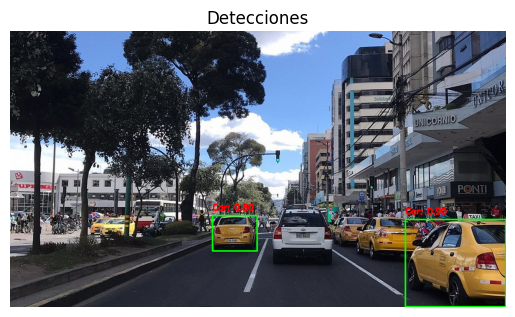

In [29]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


def read_image_rgb(path: str) -> cv2.typing.MatLike:
    image = cv2.imread(path)
    if image is None:
        raise FileNotFoundError(f"Image not found at path: {path}")
    
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def anotar(
    img_rgb: cv2.typing.MatLike,
    boxes: np.ndarray,
    scores: np.ndarray,
    labels: np.ndarray,
    class_names: dict[int, str],
):
    # Visual config
    color_box = (0, 255, 0)  # Green color for bounding boxes
    color_text = (255, 0, 0)  # Red color for text
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.5
    thickness = 2

    img_draw = img_rgb.copy()
    boxes = boxes.astype(int)  # Convertir a enteros para coordenadas de píxeles, sino falla cv2.rectangle
    
    for box, score, label in zip(boxes, scores, labels):
        x1, y1, x2, y2 = box
        thickness = 2
        image = cv2.rectangle(img_draw, (x1, y1), (x2, y2), color_box, thickness)
        caption = f"{class_names[label]}: {score:.2f}"
        cv2.putText(image, caption, (x1, y1 - 10), font, font_scale, color_text, thickness)

    # Mostrar imagen con detecciones
    plt.imshow(img_draw)
    plt.title("Detecciones")
    plt.axis("off")
    plt.show()


image = read_image_rgb("Av_Amazonas.jpg")
anotar(
    img_rgb=image,
    boxes=np.array([[717.4, 341.3, 899.99, 499.04], [367, 334.14, 448.57, 398.85]]),
    scores=np.array([0.9, 0.8]),
    labels=np.array([1, 1]),
    class_names={1: "Car"},
)

In [37]:
import cv2
from ultralytics import YOLO


def ejecutarYOLO(img_str: str) -> None:
    # Cargar modelo YOLOv26 (n -> nano para mayor velocidad)
    model = YOLO('yolo26n') # "en teoria" esto descarga el modelo

    img_path = img_str
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Hacer predicción
    results = model(img_rgb)

    # Extraer cajas, clases y confianza
    boxes = results[0].boxes.xyxy.cpu().numpy()      # Bounding boxes (x1, y1, x2, y2)
    scores = results[0].boxes.conf.cpu().numpy()     # Confianza
    labels = results[0].boxes.cls.cpu().numpy()      # Clases (índices)
    class_names = model.names                              # Diccionario id → nombre

    # Imagen original sin modificar
    plt.imshow(img_rgb)
    plt.title("Imagen original")
    plt.axis('off')
    plt.show()

    anotar(img_rgb, boxes, scores, labels, class_names)


0: 384x640 6 cars, 2 traffic lights, 4.4ms
Speed: 1.1ms preprocess, 4.4ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)


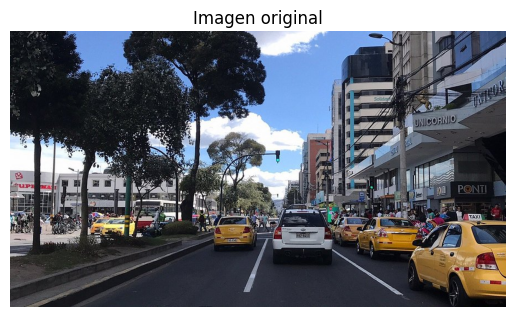

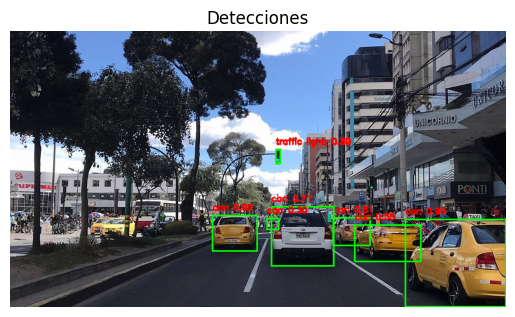

In [28]:
ejecutarYOLO("Av_Amazonas.jpg")

##### Parte 2
Llame a la misma funcion con una imagen de su elección. Analice el resultado, que clases se están prediciendo? Que clases no se están prediciendo?


0: 480x640 4 persons, 3 cars, 1 bus, 2 traffic lights, 66.1ms
Speed: 1.4ms preprocess, 66.1ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)


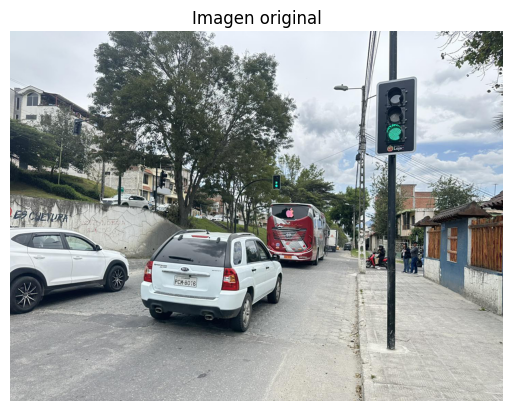

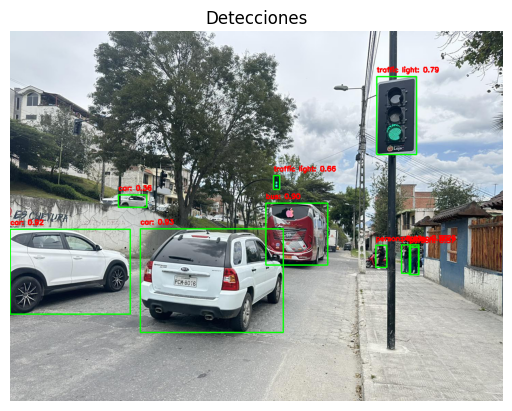

In [30]:
ejecutarYOLO("loja.png")

#### Parte 3
Compare el resultado de la clasificación obtenida con SSD vs YOLO. Hay diferencias?

In [ ]:
import torch
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from torchvision.io import read_image
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


def ejecutarSSD(img_str: str, CONF_THRESHOLD=0.4) -> None:
    # Usar GPU si está disponible
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Cargar modelo SSD preentrenado
    weights = SSD300_VGG16_Weights.COCO_V1
    class_names = weights.meta["categories"]
    model = ssd300_vgg16(weights=weights).to(device)
    model.eval()

    # Transformaciones necesarias para SSD
    transform = weights.transforms()

    # Aplicar transformaciones
    img_pil = Image.open("Av_Amazonas.jpg")
    img_rgb = img_pil.convert("RGB")
    img_tensor = transform(img_pil).unsqueeze(0).to(device)

    # Inferencia
    with torch.no_grad():
        output = model(img_tensor)[0]

    # Umbral de confianza mínimo
    CONF_THRESHOLD = 0.4

    # Obtener cajas, etiquetas, puntuaciones
    boxes = output["boxes"].cpu().numpy()
    scores = output["scores"].cpu().numpy()
    labels = output["labels"].cpu().numpy()

    # Solo mantener las mas importantes
    mask = scores >= CONF_THRESHOLD
    boxes = boxes[mask]
    scores = scores[mask]
    labels = labels[mask]

    plt.imshow(img_rgb)
    plt.title("Imagen original")
    plt.axis("off")
    plt.show()
    # Dibujo de cajas

    img_bgr = np.array(img_rgb)[:, :, ::-1].copy()
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    anotar(img_rgb, boxes, scores, labels, class_names)

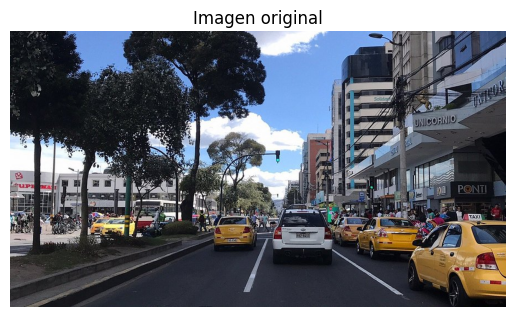

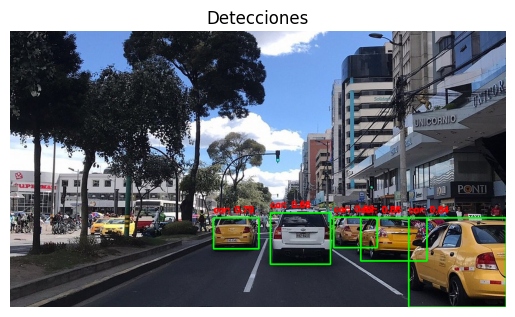

In [33]:
ejecutarSSD('Av_Amazonas.jpg', 0.2)

#### Parte 4
Compare el resultado de la clasificación obtenida con FRCNN vs YOLO. Hay diferencias?

In [34]:
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn_v2,
    FasterRCNN_ResNet50_FPN_V2_Weights,
)


def ejecutarFRCNN(img_str: str, CONF_THRESHOLD=0.4) -> None:
    # Usar GPU si está disponible
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Cargar modelo SSD preentrenado
    weights = FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1
    class_names = weights.meta["categories"]
    model = fasterrcnn_resnet50_fpn_v2(weights=weights).to(device)
    model.eval()

    # Transformaciones necesarias para SSD
    transform = weights.transforms()

    # Aplicar transformaciones
    img_pil = Image.open("Av_Amazonas.jpg")
    img_rgb = img_pil.convert("RGB")
    img_tensor = transform(img_pil).unsqueeze(0).to(device)

    # Inferencia
    with torch.no_grad():
        output = model(img_tensor)[0]

    # Umbral de confianza mínimo
    CONF_THRESHOLD = 0.4

    # Obtener cajas, etiquetas, puntuaciones
    boxes = output["boxes"].cpu().numpy()
    scores = output["scores"].cpu().numpy()
    labels = output["labels"].cpu().numpy()

    # Solo mantener las mas importantes
    mask = scores >= CONF_THRESHOLD
    boxes = boxes[mask]
    scores = scores[mask]
    labels = labels[mask]

    plt.imshow(img_rgb)
    plt.title("Imagen original")
    plt.axis("off")
    plt.show()
    # Dibujo de cajas

    img_bgr = np.array(img_rgb)[:, :, ::-1].copy()
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    anotar(img_rgb, boxes, scores, labels, class_names)

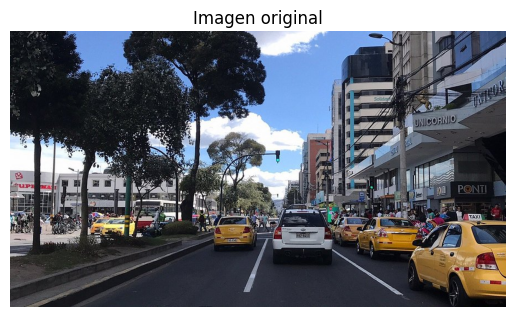

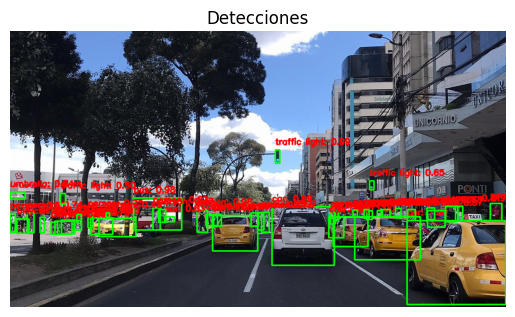

In [36]:
ejecutarFRCNN('Av_Amazonas.jpg', 0.2)